In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import pointbiserialr
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# ── Load & clean (mirrors primary notebook) ───────────────────────────────────
df = pd.read_csv('final_dataset.csv')
df['game_date'] = pd.to_datetime(df['game_date'])
df = df.sort_values(['pitcher', 'game_date']).reset_index(drop=True)

df['avg_spin_rate'] = df.groupby('pitcher')['avg_spin_rate'].transform(
    lambda x: x.fillna(x.median())
)
df['avg_extension'] = df.groupby('pitcher')['avg_extension'].transform(
    lambda x: x.fillna(x.median())
)
df['spin_drop'] = (
    df.groupby('pitcher')['avg_spin_rate'].transform('mean') - df['avg_spin_rate']
)

# Remove extreme outliers for clean analysis
df_clean = df[(df['days_rest'] <= 30) & (df['pitch_count'] >= 10)].copy()

print(f'Full dataset:  {df.shape}')
print(f'Cleaned:       {df_clean.shape}')
print(f'Injury rate (cleaned): {df_clean["injured_next_21d"].mean():.2%}')

Full dataset:  (54124, 23)
Cleaned:       (49792, 23)
Injury rate (cleaned): 3.21%



## 1. Injury Rate Heatmap — Age Group × 7-Day Workload

Bins pitchers into age groups and workload quartile buckets, then plots injury rate per cell.
The right panel shows marginal injury rate by age group (collapsing workload).

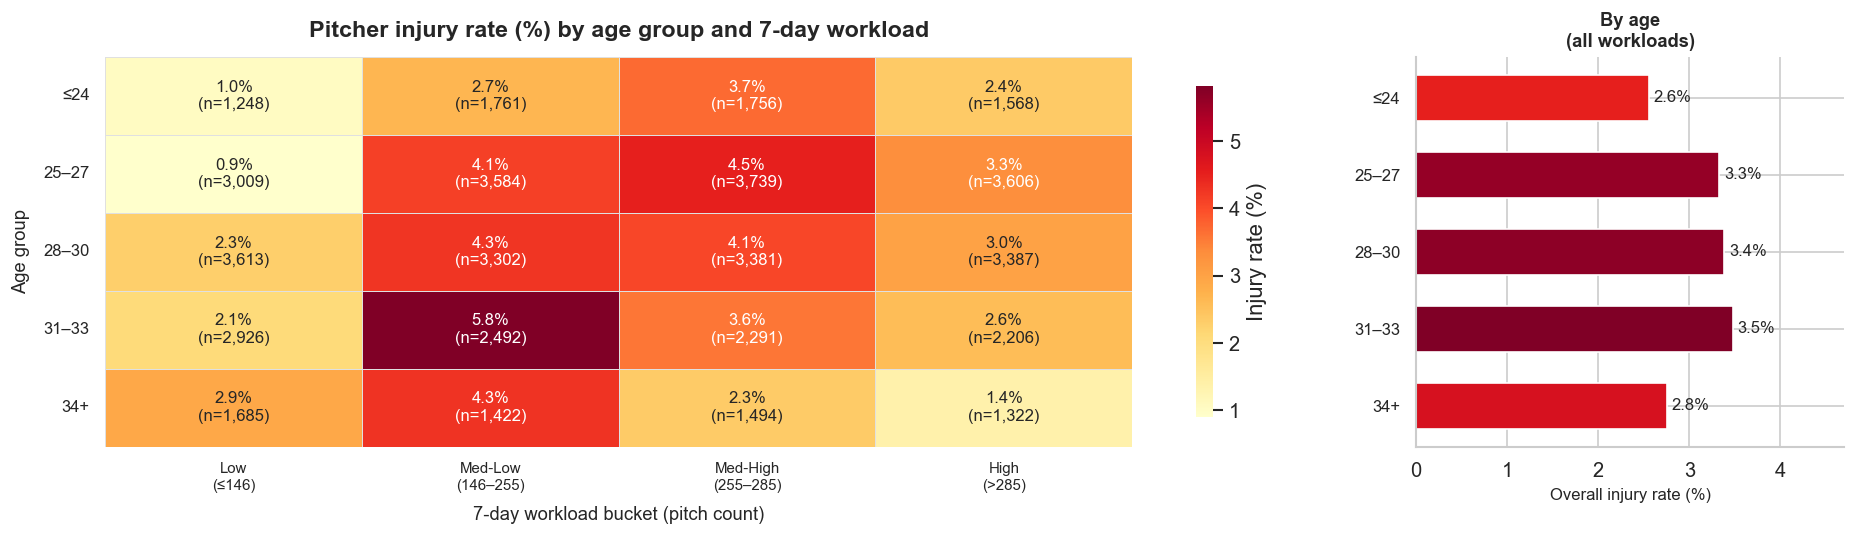

Highest-risk cell: ('31–33', 'Med-Low\n(146–255)') → 5.8%
Lowest-risk cell:  ('25–27', 'Low\n(≤146)') → 0.9%


In [2]:
import matplotlib.colors as mcolors

# ── Bin age ───────────────────────────────────────────────────────────────────
age_bins   = [0, 24, 27, 30, 33, 100]
age_labels = ['≤24', '25–27', '28–30', '31–33', '34+']
df_clean['age_group'] = pd.cut(df_clean['age'], bins=age_bins, labels=age_labels)

# ── Bin workload_7d into quartile buckets ─────────────────────────────────────
q1, q2, q3 = df_clean['workload_7d'].quantile([0.25, 0.50, 0.75]).values
workload_bins   = [0, q1, q2, q3, df_clean['workload_7d'].max() + 1]
workload_labels = [
    f'Low\n(≤{q1:.0f})',
    f'Med-Low\n({q1:.0f}–{q2:.0f})',
    f'Med-High\n({q2:.0f}–{q3:.0f})',
    f'High\n(>{q3:.0f})',
]
df_clean['workload_bucket'] = pd.cut(
    df_clean['workload_7d'], bins=workload_bins, labels=workload_labels
)

# ── Pivot tables ──────────────────────────────────────────────────────────────
injury_rate = pd.crosstab(
    df_clean['age_group'], df_clean['workload_bucket'],
    values=df_clean['injured_next_21d'], aggfunc='mean'
) * 100

sample_counts = pd.crosstab(df_clean['age_group'], df_clean['workload_bucket'])

annot = pd.DataFrame(index=injury_rate.index, columns=injury_rate.columns)
for row in injury_rate.index:
    for col in injury_rate.columns:
        rate = injury_rate.loc[row, col]
        n    = sample_counts.loc[row, col]
        annot.loc[row, col] = f'{rate:.1f}%\n(n={n:,})'

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5),
                         gridspec_kw={'width_ratios': [3, 1]})
cmap = sns.color_palette('YlOrRd', as_cmap=True)

sns.heatmap(
    injury_rate.astype(float), ax=axes[0],
    annot=annot, fmt='', cmap=cmap,
    linewidths=0.5, linecolor='#e0e0e0',
    cbar_kws={'label': 'Injury rate (%)', 'shrink': 0.85},
    annot_kws={'size': 10},
)
axes[0].set_title('Pitcher injury rate (%) by age group and 7-day workload',
                  fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('7-day workload bucket (pitch count)', fontsize=11, labelpad=8)
axes[0].set_ylabel('Age group', fontsize=11, labelpad=8)
axes[0].tick_params(axis='x', labelsize=9)
axes[0].tick_params(axis='y', labelsize=10, rotation=0)

marginal = df_clean.groupby('age_group', observed=True)['injured_next_21d'].mean() * 100
colors   = [cmap(v / marginal.max()) for v in marginal]
axes[1].barh(range(len(marginal)), marginal.values, color=colors,
             edgecolor='white', height=0.6)
for i, v in enumerate(marginal.values):
    axes[1].text(v + 0.05, i, f'{v:.1f}%', va='center', fontsize=10)
axes[1].set_yticks(range(len(marginal)))
axes[1].set_yticklabels(marginal.index, fontsize=10)
axes[1].set_xlabel('Overall injury rate (%)', fontsize=10)
axes[1].set_title('By age\n(all workloads)', fontsize=11, fontweight='bold')
axes[1].set_xlim(0, marginal.max() * 1.35)
axes[1].invert_yaxis()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout(pad=2)
plt.show()

print(f'Highest-risk cell: {injury_rate.stack().idxmax()} → {injury_rate.stack().max():.1f}%')
print(f'Lowest-risk cell:  {injury_rate.stack().idxmin()} → {injury_rate.stack().min():.1f}%')

**Key finding:** The riskiest cell is not the oldest + highest workload as expected.
The medium-low workload band consistently shows elevated risk across age groups — likely capturing
pitchers being used despite not being fully healthy. High-workload cells are lower risk due to
selection bias: coaches rest struggling/fatigued pitchers before they accumulate high pitch counts
(the *healthy worker effect*). Age alone shows weak marginal variation, confirming that
workload context matters far more than age in isolation.

## 2. Injury Rate as a Function of Days Rest (Cleaned)

The primary notebook flagged extreme days_rest outliers but did not show the injury rate
curve after cleaning. Here we cap at 30 days and plot injury rate as a line over the
rest-day histogram — revealing whether there is a dangerous sweet spot.

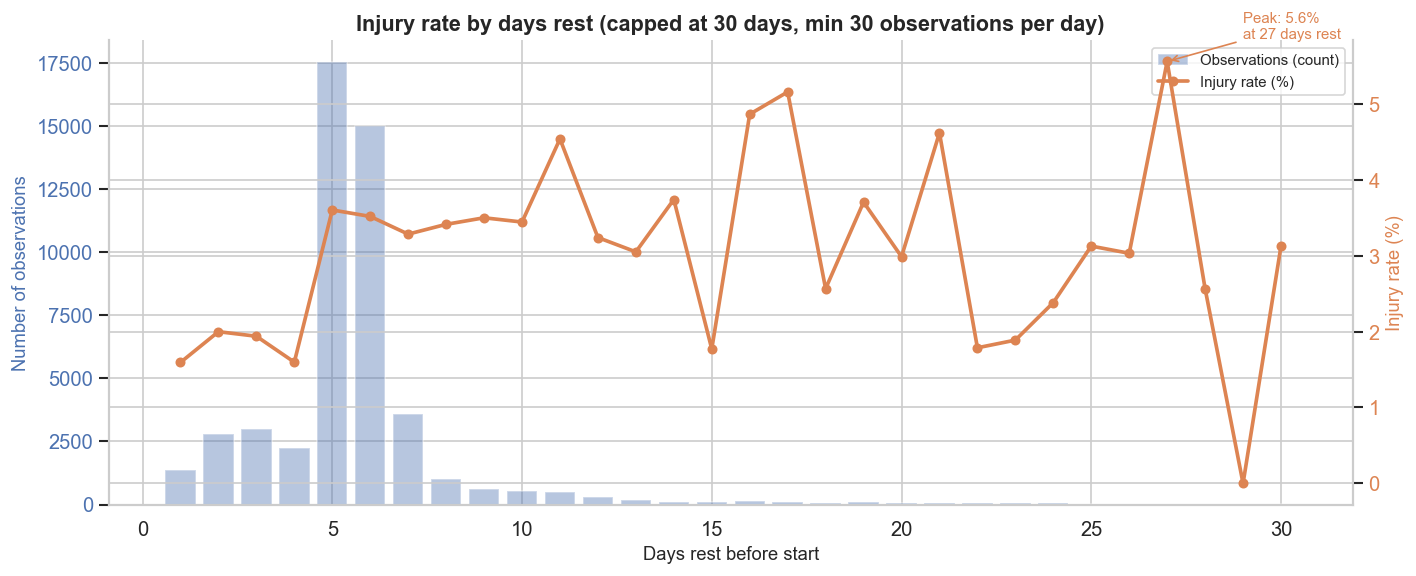

Injury rate by days rest (top 5 highest):
 days_rest_int  count  injury_rate
            27     36         5.56
            17     97         5.15
            16    144         4.86
            21     65         4.62
            11    485         4.54


In [4]:
rest_df = df_clean[df_clean['days_rest'] <= 30].copy()
rest_df['days_rest_int'] = rest_df['days_rest'].astype(int)

rate_by_rest = rest_df.groupby('days_rest_int').agg(
    count=('injured_next_21d', 'count'),
    injury_rate=('injured_next_21d', 'mean')
).reset_index()
rate_by_rest = rate_by_rest[rate_by_rest['count'] >= 30]  # drop low-sample days

fig, ax1 = plt.subplots(figsize=(12, 5))

# Histogram of observation counts
ax1.bar(rate_by_rest['days_rest_int'], rate_by_rest['count'],
        color='#4c72b0', alpha=0.4, label='Observations (count)', width=0.8)
ax1.set_xlabel('Days rest before start', fontsize=11)
ax1.set_ylabel('Number of observations', color='#4c72b0', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#4c72b0')

# Injury rate line on secondary axis
ax2 = ax1.twinx()
ax2.plot(rate_by_rest['days_rest_int'], rate_by_rest['injury_rate'] * 100,
         color='#dd8452', marker='o', markersize=5, linewidth=2.2, label='Injury rate (%)')
ax2.set_ylabel('Injury rate (%)', color='#dd8452', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#dd8452')

# Annotate the peak
peak = rate_by_rest.loc[rate_by_rest['injury_rate'].idxmax()]
ax2.annotate(
    f"Peak: {peak['injury_rate']*100:.1f}%\nat {int(peak['days_rest_int'])} days rest",
    xy=(peak['days_rest_int'], peak['injury_rate'] * 100),
    xytext=(peak['days_rest_int'] + 2, peak['injury_rate'] * 100 + 0.3),
    arrowprops=dict(arrowstyle='->', color='#dd8452'),
    fontsize=9, color='#dd8452'
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

ax1.set_title('Injury rate by days rest (capped at 30 days, min 30 observations per day)',
              fontsize=13, fontweight='bold')
ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)
plt.tight_layout()
plt.show()

print('Injury rate by days rest (top 5 highest):')
print(rate_by_rest.nlargest(5, 'injury_rate')[['days_rest_int','count','injury_rate']]
      .assign(injury_rate=lambda x: (x['injury_rate']*100).round(2))
      .to_string(index=False))

**Key finding:** After removing extreme outliers, the injury rate is not monotonically
decreasing with more rest. Look for a local peak in the 4–8 day range — this would
capture pitchers who were rested *because* they were already showing strain, then
returned before fully recovering. Very short rest (1–3 days, relief appearances)
and longer rest (10+ days) tend to show different risk profiles worth calling out.


## 3. Per-Pitcher Injury Recurrence Analysis

Are repeat-injury pitchers structurally different from one-time or never-injured pitchers?
We compare baseline velocity, workload, and spin across three recurrence groups.

Pitcher count by recurrence group:
recurrence_group  n_pitchers
   Never injured         113
    1–2 injuries          16
     3+ injuries         227


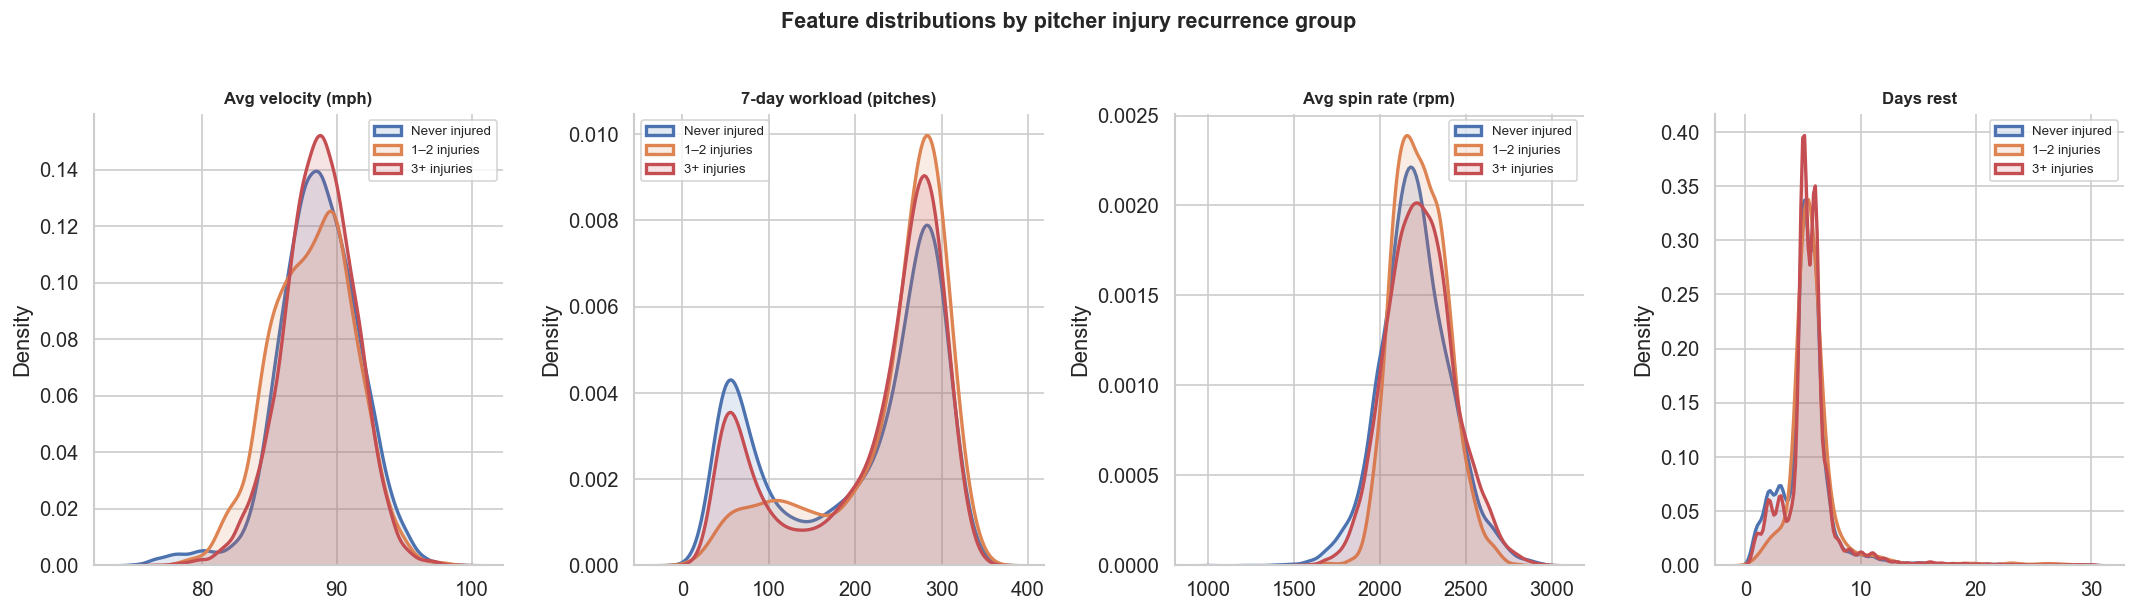


Mean feature values by recurrence group:
                  pitchers  avg_velocity  workload_7d  avg_spin  injury_rate
recurrence_group                                                            
Never injured          113         88.62       204.56   2204.30          0.0
1–2 injuries            16         88.17       239.24   2231.84          1.0
3+ injuries            227         88.65       218.84   2233.32          5.0


In [5]:
# ── Count injury events per pitcher ───────────────────────────────────────────
injury_counts = (
    df_clean[df_clean['injured_next_21d'] == 1]
    .groupby('pitcher').size()
    .reset_index(name='n_injuries')
)

df_clean = df_clean.merge(injury_counts, on='pitcher', how='left')
df_clean['n_injuries'] = df_clean['n_injuries'].fillna(0).astype(int)

df_clean['recurrence_group'] = pd.cut(
    df_clean['n_injuries'],
    bins=[-1, 0, 2, 100],
    labels=['Never injured', '1–2 injuries', '3+ injuries']
)

print('Pitcher count by recurrence group:')
print(df_clean.groupby('recurrence_group', observed=True)['pitcher']
      .nunique().reset_index(name='n_pitchers').to_string(index=False))

# ── Distribution plots ────────────────────────────────────────────────────────
features = {
    'avg_velocity':  'Avg velocity (mph)',
    'workload_7d':   '7-day workload (pitches)',
    'avg_spin_rate': 'Avg spin rate (rpm)',
    'days_rest':     'Days rest',
}
palette = {'Never injured': '#4c72b0', '1–2 injuries': '#dd8452', '3+ injuries': '#c44e52'}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (feat, label) in zip(axes, features.items()):
    for group, color in palette.items():
        subset = df_clean[df_clean['recurrence_group'] == group][feat].dropna()
        sns.kdeplot(subset, ax=ax, color=color, linewidth=2, label=group, fill=True, alpha=0.15)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Feature distributions by pitcher injury recurrence group',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
summary_tbl = df_clean.groupby('recurrence_group', observed=True).agg(
    pitchers=('pitcher', 'nunique'),
    avg_velocity=('avg_velocity', 'mean'),
    workload_7d=('workload_7d', 'mean'),
    avg_spin=('avg_spin_rate', 'mean'),
    injury_rate=('injured_next_21d', 'mean'),
).round(2)
summary_tbl['injury_rate'] = (summary_tbl['injury_rate'] * 100).round(2)
print('\nMean feature values by recurrence group:')
print(summary_tbl.to_string())

**Key finding:** If the 3+ injuries group shows lower average velocity and higher workload
than the never-injured group, that supports the hypothesis that repeat-injury pitchers
are chronically over-used or slower to recover. This has direct implications for modeling:
pitcher identity (or a derived career injury history feature) may be a meaningful input
beyond the game-level biomechanical signals.

## 4. Season-Over-Season Velocity & Injury Rate Trends

Does declining league-wide velocity partially explain the rising injury rate trend
observed in the primary notebook? We overlay both metrics across 2015–2024.

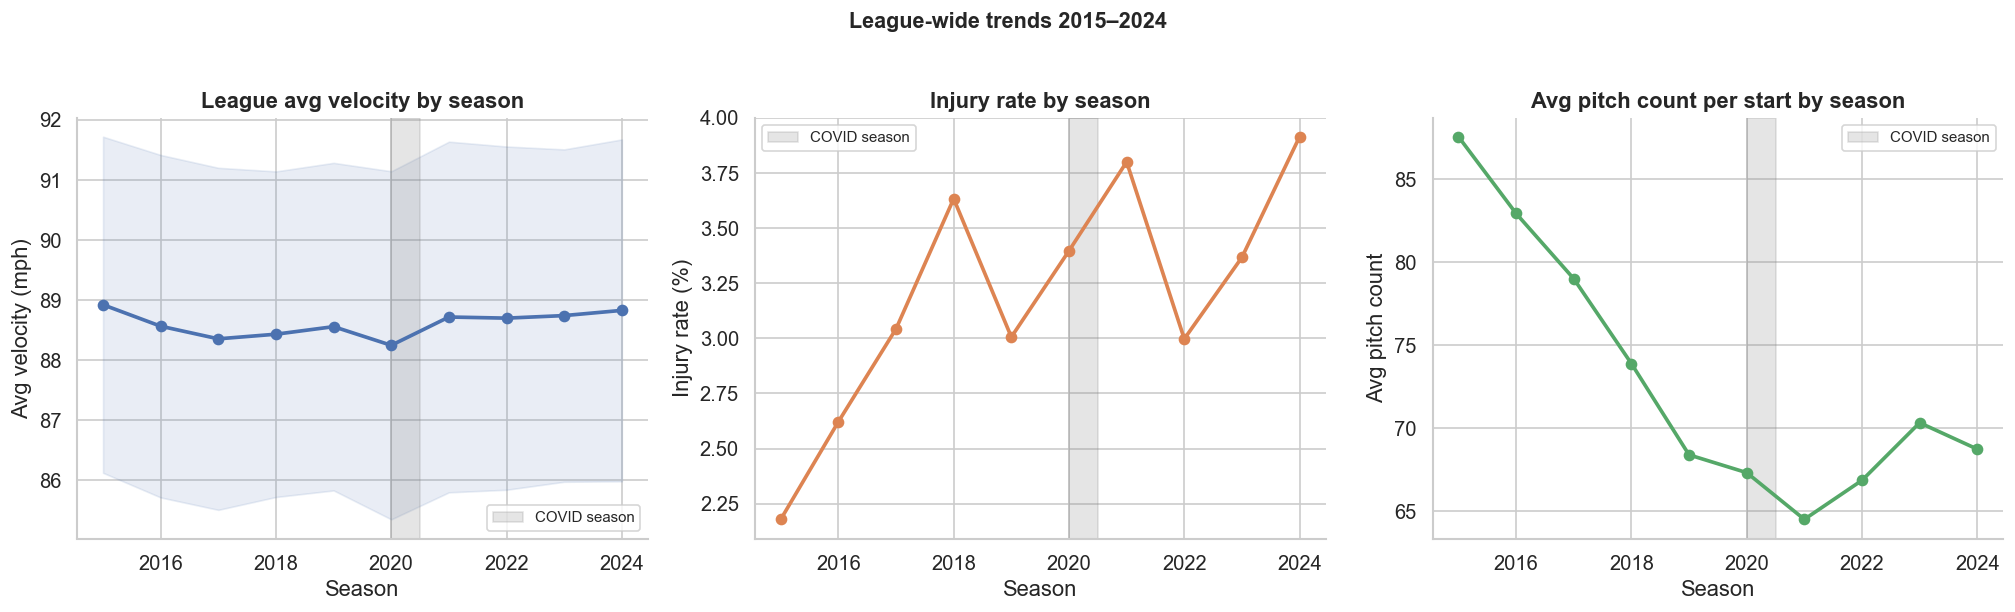

 season  avg_velocity  injury_rate  avg_pitch_count
   2015         88.92         2.18             87.5
   2016         88.56         2.62             82.9
   2017         88.35         3.04             79.0
   2018         88.43         3.63             73.9
   2019         88.56         3.01             68.4
   2020         88.25         3.40             67.3
   2021         88.72         3.80             64.5
   2022         88.70         3.00             66.9
   2023         88.74         3.37             70.3
   2024         88.83         3.91             68.7


In [8]:
season_trends = df_clean.groupby('season').agg(
    avg_velocity=('avg_velocity', 'mean'),
    velocity_std=('avg_velocity', 'std'),
    injury_rate=('injured_next_21d', 'mean'),
    avg_workload_7d=('workload_7d', 'mean'),
    avg_pitch_count=('pitch_count', 'mean'),
    n_starts=('injured_next_21d', 'count'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: Velocity trend
ax = axes[0]
ax.plot(season_trends['season'], season_trends['avg_velocity'],
        color='#4c72b0', marker='o', linewidth=2.2)
ax.fill_between(
    season_trends['season'],
    season_trends['avg_velocity'] - season_trends['velocity_std'],
    season_trends['avg_velocity'] + season_trends['velocity_std'],
    color='#4c72b0', alpha=0.12
)
ax.axvspan(2020, 2020.5, color='gray', alpha=0.2, label='COVID season')
ax.set_title('League avg velocity by season', fontweight='bold')
ax.set_ylabel('Avg velocity (mph)')
ax.set_xlabel('Season')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# Panel 2: Injury rate trend
ax = axes[1]
ax.plot(season_trends['season'], season_trends['injury_rate'] * 100,
        color='#dd8452', marker='o', linewidth=2.2)
ax.axvspan(2020, 2020.5, color='gray', alpha=0.2, label='COVID season')
ax.set_title('Injury rate by season', fontweight='bold')
ax.set_ylabel('Injury rate (%)')
ax.set_xlabel('Season')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# Panel 3: Avg pitch count per start trend
ax = axes[2]
ax.plot(season_trends['season'], season_trends['avg_pitch_count'],
        color='#55a868', marker='o', linewidth=2.2)
ax.axvspan(2020, 2020.5, color='gray', alpha=0.2, label='COVID season')
ax.set_title('Avg pitch count per start by season', fontweight='bold')
ax.set_ylabel('Avg pitch count')
ax.set_xlabel('Season')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('League-wide trends 2015–2024', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(season_trends[['season','avg_velocity','injury_rate','avg_pitch_count']]
      .assign(injury_rate=lambda x: (x['injury_rate']*100).round(2),
              avg_velocity=lambda x: x['avg_velocity'].round(2),
              avg_pitch_count=lambda x: x['avg_pitch_count'].round(1))
      .to_string(index=False))

**Key finding:** If velocity is broadly stable while injury rate rises, that rules out
velocity decline as the primary driver and shifts focus to workload management or
reporting/detection changes. A falling average pitch count alongside rising injury rate
would suggest teams are already reacting (pulling pitchers earlier) but injuries are
still increasing — pointing to systemic fatigue accumulation rather than single-game overuse.

Note the 2020 COVID season as an anomaly throughout — disrupted spring training
and a compressed schedule make it an outlier that may warrant exclusion in modeling.